# Stomatal Patterning Phenotype (SPP) of maize — pySPP hands-on demo

Partially reproduces the Python-computable core of:
**"Spatial analysis of cell patterning to aid genetic and phenotypic understanding of grass stomatal density: A case study in maize"**, *Plant Phenomics Journal* (2026), DOI: [10.1002/ppj2.70066](https://doi.org/10.1002/ppj2.70066) — preprint: bioRxiv v1 [10.1101/2025.05.21.655366](https://www.biorxiv.org/content/10.1101/2025.05.21.655366v1).

**What you will do:** run the authors' own [pySPP](https://github.com/jgerardhodge/pySPP) library (pinned commit `84bd2c0`) on their shipped example annotations (`data/maize_example_data.csv`, 2016 field trial) to (1) build rank-ordered Manhattan nearest-neighbor tables, (2) render the SPP as a 2-D kernel density distribution (KDD) heatmap, (3) extract core component traits, and (4) compare against a random-placement null model (Observed-vs-Expected score).

**Scope and honest limitations (English / 日本語)**
- This is a **partial demonstration** of workflow steps 1–4 (the pySPP section) on the authors' small shipped example — **not** a full-paper reproduction. It does not reproduce the R-based dimension reduction, structural equation model, heritability, or QTL mapping (no scripts published), nor image annotation (Mask R-CNN weights are not distributed), nor dataset-level results over all RILs.
- **部分的なデモです。** 本ノートブックは論文ワークフローの Python 部分（ステップ1〜4）を著者提供のサンプルデータで実行するものであり、R による SEM・遺伝率推定・QTL 解析（スクリプト非公開）や Mask R-CNN によるアノテーション（重み非公開）は含みません。単一サンプル実行であり、論文の集団レベルの結果の検証ではありません。
- Code provenance: author code (`SPP.py`) is used as-is from the pinned commit; the pipeline cells are a faithful, lightly refactored adaptation of the authors' own `SPP_Binder_Demo.ipynb` from the same commit. AI-assisted adaptation was limited to reorganizing those author cells for Colab; the authors did not provide this Colab notebook itself.

**Runtime:** select **Runtime → Change runtime type → CPU** (this demo needs no GPU; everything is pandas/numpy/scipy/matplotlib).

## 1. Setup: fetch the pinned author code and example data

Download the pinned pySPP revision (commit `84bd2c0...`, MIT license) and the example annotation CSV into `/content`, and record SHA-256 checksums for provenance. The CSV (sample data) is downloaded **only here in Colab** and stays on this VM.
**入力データと著者コードをピン留めしたコミットから Colab 内に取得し、チェックサムを記録します。**

In [ ]:
import hashlib, pathlib, urllib.request

BASE = "https://raw.githubusercontent.com/jgerardhodge/pySPP/84bd2c078a54087118ea7c72716dc48697244903"
SPP_SHA256 = "314108ccd88995b967a757e52a8a46a70e4993629d64cbd1bdfffd84d9ce939e"

for path in ["SPP.py", "data/maize_example_data.csv"]:
    dest = pathlib.Path("/content") / path
    dest.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(f"{BASE}/{path}", dest)
    digest = hashlib.sha256(dest.read_bytes()).hexdigest()
    print(f"{path}: {dest.stat().st_size} bytes  sha256={digest}")

got = hashlib.sha256(pathlib.Path("/content/SPP.py").read_bytes()).hexdigest()
assert got == SPP_SHA256, f"SPP.py checksum mismatch: {got}"
print("SPP.py checksum verified against pinned commit.")

SPP.py: 58333 bytes  sha256=314108ccd88995b967a757e52a8a46a70e4993629d64cbd1bdfffd84d9ce939e


data/maize_example_data.csv: 758200 bytes  sha256=1a3b13011bbcb3068a86a9d29ce4e9dc4dbf4fa20cfa6e7d7ffbbcf8136359f4
SPP.py checksum verified against pinned commit.


## 2. Environment check

The pinned `requirements.txt` needs pandas, numpy, matplotlib, scipy — all preinstalled in Colab. We print the actual versions we ran on so you can compare.
**依存ライブラリは Colab に同梱済みです。実際に使用したバージョンを表示します。**

In [ ]:
import sys, pandas, numpy, matplotlib, scipy
print("Python", sys.version.split()[0])
print("pandas", pandas.__version__, "| numpy", numpy.__version__,
      "| matplotlib", matplotlib.__version__, "| scipy", scipy.__version__)
import SPP
print("pySPP SPP.py loaded from:", SPP.__file__)

Python 3.13.15
pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | scipy 1.16.3


pySPP SPP.py loaded from: /content/SPP.py


## 3. Load and prune the example annotations

Each row is one stomatal complex annotated by the authors' Mask R-CNN pipeline: centroid (px), mask length/width/area, plus genotype/plot/replicate/FOV identifiers. Following the authors' demo we (a) drop rows flagged `edge`, (b) keep only the columns `stomata_rankedNN` expects, (c) convert pixels→µm with the authors' calibration `px2um_scale = 0.64`, and (d) prune origins within ~50 µm of the image border (`offset = 0.64 × 50` px) so edge artifacts do not bias the ~50 µm nearest-neighbor scale. These calibration constants are specific to the authors' optical tomographer (their comment in the demo notebook).
**個体データを読み込み、エッジ行の除去・px→µm 変換・画像端近傍の原点除去を行います（著者のキャリブレーション値を使用）。**

In [ ]:
import pandas as pd, numpy as np

data = pd.read_csv("/content/data/maize_example_data.csv")
print("rows loaded:", len(data), "| genotypes:", data['Genotype'].nunique())
data = data.loc[data['note'] != 'edge']
data = data.iloc[:, [0, 1, 2, 3, 8, 9, 11, 10, 7, 15]]  # author demo column order
print("rows after edge filter:", len(data))
data.head()

rows loaded: 4701 | genotypes: 4
rows after edge filter: 4184


,Genotype,Fieldplot,Replicate,FOV,x_center,y_center,length,width,stoma_area,length_width_ratio
0,Z019E0047,496,1,1,368.336329,359.488934,45.634884,22.203307,792.236328,2.055319
2,Z019E0047,496,1,1,409.847069,458.738320,41.338777,25.113106,811.767578,1.646104
3,Z019E0047,496,1,1,224.035644,246.915438,45.587822,26.944596,963.134766,1.691910
4,Z019E0047,496,1,1,328.098236,482.657926,38.108106,24.985123,745.849609,1.525232
5,Z019E0047,496,1,1,85.817563,67.056679,37.246189,32.136650,938.720703,1.158994


We then apply the authors' edge-pruning rule and unit conversion: origins within ~50 µm of a border are excluded, and centroid/mask dimensions are scaled from pixels to µm (`x_center` → `x_center_um`, etc.) using the 0.64 µm/px calibration.
**続いて、画像端近傍の原点除去と px→µm 変換を適用します。**

In [ ]:
px2um_scale = 0.64   # µm per pixel (authors' tomographer calibration)
img_size = 512       # image is 512 x 512 px
offset = px2um_scale * 50  # prune origins closer than ~50 µm to a border

data_pruned = data.iloc[np.where(
    (data['x_center'] > offset) & (data['x_center'] < img_size - offset) &
    (data['y_center'] > offset) & (data['y_center'] < img_size - offset))[0], ]
print("origins retained after edge pruning:", len(data_pruned))

SC_data = data_pruned.rename(columns={'x_center': 'x_center_um', 'y_center': 'y_center_um',
                                      'length': 'length_um', 'width': 'width_um',
                                      'stoma_area': 'stoma_area_um.2'})
for col in ['x_center_um', 'y_center_um', 'length_um', 'width_um']:
    SC_data[col] = SC_data[col] * px2um_scale
SC_data['stoma_area_um.2'] = SC_data['stoma_area_um.2'] * px2um_scale**2
SC_data.head()

origins retained after edge pruning: 3473


,Genotype,Fieldplot,Replicate,FOV,x_center_um,y_center_um,length_um,width_um,stoma_area_um.2,length_width_ratio
0,Z019E0047,496,1,1,235.735251,230.072918,29.206326,14.210116,324.5,2.055319
2,Z019E0047,496,1,1,262.302124,293.592525,26.456817,16.072388,332.5,1.646104
3,Z019E0047,496,1,1,143.382812,158.025881,29.176206,17.244542,394.5,1.691910
5,Z019E0047,496,1,1,54.923240,42.916274,23.837561,20.567456,384.5,1.158994
6,Z019E0047,496,1,1,196.860009,291.805763,25.680745,15.340757,308.5,1.674021


## 4. Phase 1 — rank-ordered nearest neighbors (Manhattan, 5 ranks)

For every origin stoma, `SPP.stomata_rankedNN` finds its 5 nearest neighbors by **Manhattan distance** (the metric the paper uses because grass stomata are arranged in linear cell files). We loop per genotype × fieldplot × replicate × FOV exactly as in the authors' demo, printing per-genotype stomatal density (stomata per 512×512 px field, with the authors' ×1.25 field-area factor).
**原点気孔ごとにマンハッタン距離で 5 個の順位付き近傍を計算します（論文フェーズ1）。**

In [ ]:
import datetime, SPP

rankedNNs = pd.DataFrame(columns=['Genotype', 'Fieldplot', 'Replicate', 'FOV', 'Current_SC',
                                  'NN_rank', 'NN_dist', 'Origin_X', 'Origin_Y', 'NN_x', 'NN_y',
                                  'NN_dist_xdiff', 'NN_dist_ydiff'])

start = datetime.datetime.now()
for cur_geno in np.unique(data_pruned['Genotype']):
    SD_counts = []
    for fld in np.unique(data_pruned[data_pruned['Genotype'] == cur_geno]['Fieldplot']):
        for rep in np.unique(data_pruned[(data_pruned['Genotype'] == cur_geno) &
                                         (data_pruned['Fieldplot'] == fld)]['Replicate']):
            fovs = np.unique(data_pruned[(data_pruned['Genotype'] == cur_geno) &
                                         (data_pruned['Fieldplot'] == fld) &
                                         (data_pruned['Replicate'] == rep)]['FOV'])
            for fov in fovs:
                sample = data_pruned.loc[(data_pruned['Genotype'] == cur_geno) &
                                         (data_pruned['Fieldplot'] == fld) &
                                         (data_pruned['Replicate'] == rep) &
                                         (data_pruned['FOV'] == fov)]
                SD_counts.append(len(sample))
                curNNs = SPP.stomata_rankedNN(sample, 'M', 5)
                rankedNNs = curNNs if len(rankedNNs) == 0 else pd.concat(
                    [rankedNNs, curNNs], axis=0, ignore_index=True)
    print("Genotype", cur_geno, ": avg SD =", np.round(np.mean(SD_counts), 2),
          "stomata/field over", len(SD_counts), "images")
print("ranked NN rows:", len(rankedNNs),
      "| elapsed:", (datetime.datetime.now() - start).total_seconds(), "s")

Genotype Z019E0047 : avg SD = 51.8 stomata/field over 20 images


Genotype Z019E0052 : avg SD = 63.8 stomata/field over 15 images


Genotype Z019E0106 : avg SD = 47.7 stomata/field over 20 images


Genotype Z019E0140 : avg SD = 26.3 stomata/field over 20 images
ranked NN rows: 17365 | elapsed: 6.286097 s


## 5. Phase 2 — the SPP heatmap (kernel density distribution)

The paper defines the SPP as the 2-D probability surface of finding a neighbor at a given offset from the origin: ranked-NN offsets are binned on a **1 µm² kernel grid over ±150 µm** in x and y (verified in the bioRxiv v1 text), with `rankmethod='avgrank'` averaging ranks 1–5. We render one replicate (genotype Z019E0047, plot 496, replicate 1) so you can see the two in-file hotspots flanking the origin box — the grass "cell file" signature.
**順位付き近傍から SPP（カーネル密度分布）を ±150 µm・1 µm² 解像度で描画します（フェーズ2）。**

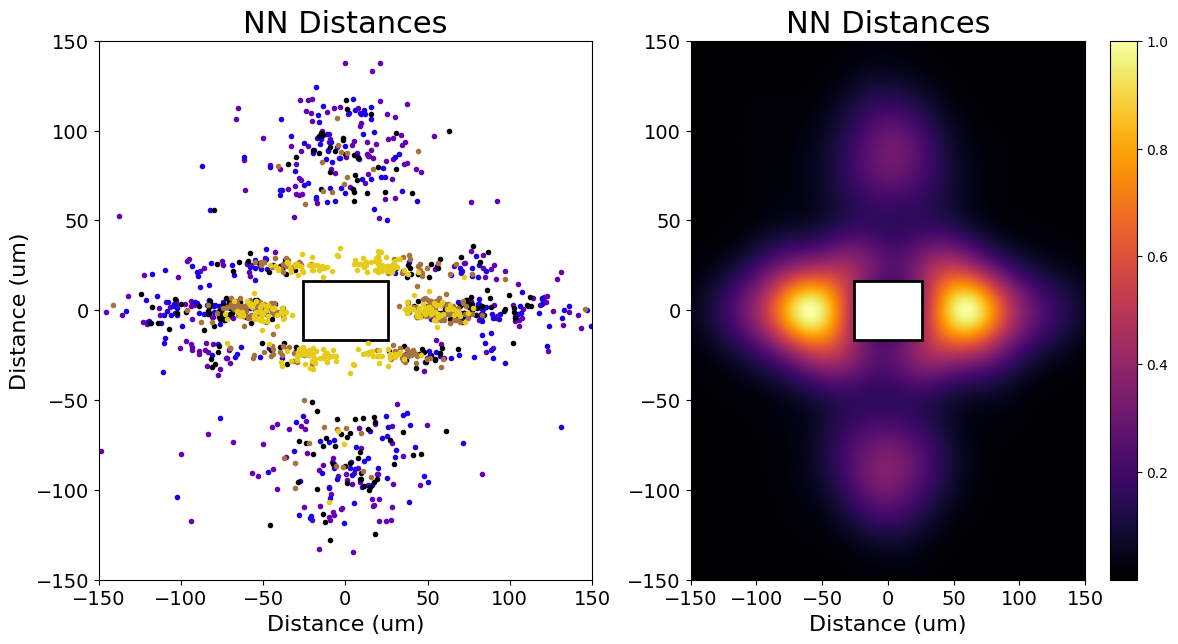

genotype Z019E0047 replicate 1 : SD = 65.5 stomata/field, SCL = 25.87 µm, SCW = 16.32 µm
Z surface shape: (300, 300) (rows=y, cols=x; each kernel = 1 µm²)


In [ ]:
ranks, xbound, ybound = 5, 150, 150

cur_geno, fld, rep = 'Z019E0047', 496, 1
AccNNs = rankedNNs[rankedNNs['Genotype'] == cur_geno]

SD_counts, SC_lengths, SC_widths = [], [], []
for fov in np.unique(AccNNs['FOV']):
    idx = np.where((SC_data['Genotype'] == cur_geno) & (SC_data['Fieldplot'] == fld) &
                   (SC_data['Replicate'] == rep) & (SC_data['FOV'] == fov))[0]
    rep_img = SC_data.iloc[idx]
    SD_counts.append(rep_img.shape[0] * 1.25)
    SC_lengths.append(np.round(np.mean(rep_img['length_um']), 2))
    SC_widths.append(np.round(np.mean(rep_img['width_um']), 2))
SD_mu = np.round(np.mean(SD_counts), 2)
SCL_mu = np.round(np.mean(SC_lengths), 2)
SCW_mu = np.round(np.mean(SC_widths), 2)

RepNNs = AccNNs.iloc[np.where((AccNNs['Fieldplot'] == fld) & (AccNNs['Replicate'] == rep))[0], :]
RepZ = SPP.stomata_KDDs(RepNNs, xbound, ybound, SCL_mu, SCW_mu, ranks, 'avgrank', plotting=True)
print("genotype", cur_geno, "replicate", rep,
      ": SD =", SD_mu, "stomata/field, SCL =", SCL_mu, "µm, SCW =", SCW_mu, "µm")
print("Z surface shape:", RepZ.shape, "(rows=y, cols=x; each kernel = 1 µm²)")

## 6. Phase 3 — extract the core component traits

The paper's core trait set comes from flattening the SPP into horizontal/vertical density profiles (`stomata_KDD_hist`) and annotating inflection points of the vertical profile (`stomata_KDD_deriv_anno`): trench distance, side-file peak distance, and the in-file / adjacent-file / trench / side-file-peak probabilities with their origin fold-changes. These are the "cell size, cell packing, and positional probability" component traits the paper feeds into its SEM (the SEM itself is out of scope here).
**SPP を平坦化した分布から溝距離・ピーク距離・各領域の確率と fold-change を抽出します（フェーズ3）。**

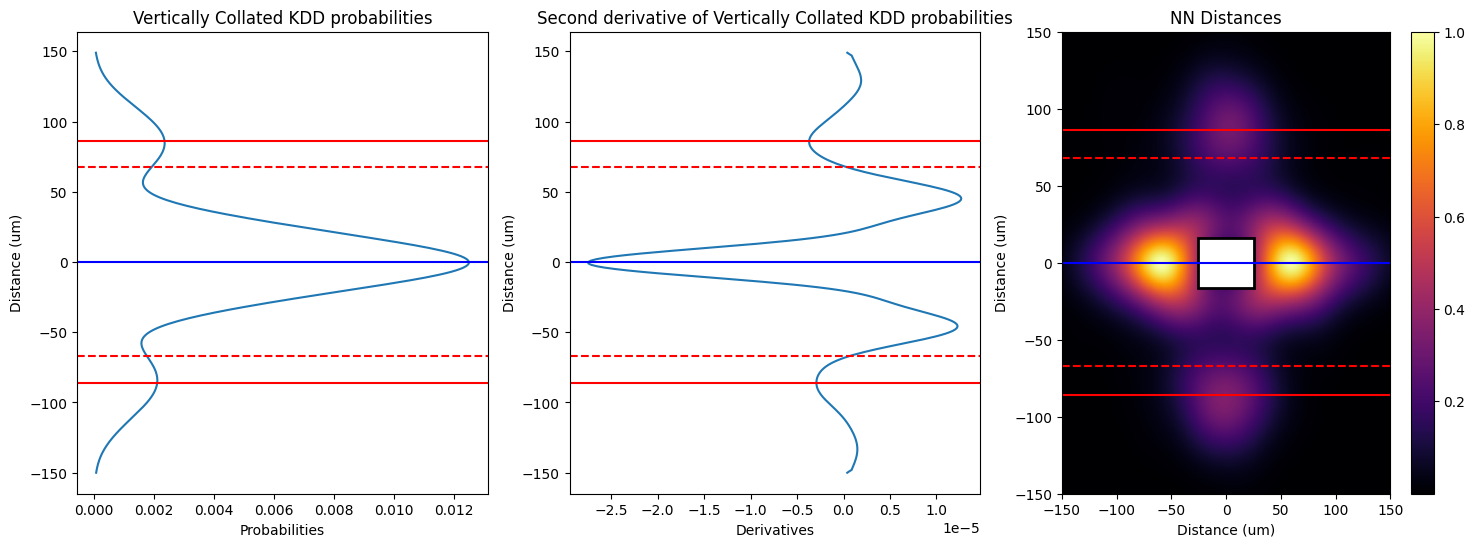

trench distance from origin = 67.5 µm
side-file peak distance from origin = 86.0 µm
adjacent-file:origin fold-change = -0.337
trench:origin fold-change = -0.851
side-file peak:origin fold-change = -0.821
probabilities: in-file = 0.012 , adjacent-file = 0.012 , trench = 0.002 , side-file peak = 0.002


In [ ]:
RepHP, RepVP = SPP.stomata_KDD_hist(RepNNs, RepZ, xbound, ybound, SCL_mu, SCW_mu, ranks, False)
RepZ1 = SPP.stomata_KDDs(RepNNs, xbound, ybound, SCL_mu, SCW_mu, 1, 'currank', False)
RepHP1, RepVP1 = SPP.stomata_KDD_hist(RepNNs, RepZ1, xbound, ybound, SCL_mu, SCW_mu, 1, False)

origin_trench_dist, origin_peak_dist, trenchprob_FC, Peaksprob_FC = \
    SPP.stomata_KDD_deriv_anno(RepVP, RepZ, xbound, ybound, SCL_mu, SCW_mu, True)

IF_prob = RepVP[int((len(RepVP) / 2))]
AF_prob = (RepVP[int((len(RepVP) / 2) - (SCW_mu / 2))] +
           RepVP[int((len(RepVP) / 2) + (SCW_mu / 2))]) / 2
Tr_prob = (RepVP[int((len(RepVP) / 2) - origin_trench_dist)] +
           RepVP[int((len(RepVP) / 2) + origin_trench_dist)]) / 2
SP_prob = (RepVP[int((len(RepVP) / 2) - origin_peak_dist)] +
           RepVP[int((len(RepVP) / 2) + origin_peak_dist)]) / 2
Adjacprob_FC = (AF_prob - RepVP1[int((len(RepVP1) / 2))]) / RepVP1[int((len(RepVP1) / 2))]

print("trench distance from origin =", origin_trench_dist, "µm")
print("side-file peak distance from origin =", origin_peak_dist, "µm")
print("adjacent-file:origin fold-change =", np.round(Adjacprob_FC, 3))
print("trench:origin fold-change =", np.round(trenchprob_FC, 3))
print("side-file peak:origin fold-change =", np.round(Peaksprob_FC, 3))
print("probabilities: in-file =", np.round(IF_prob, 3),
      ", adjacent-file =", np.round(AF_prob, 3),
      ", trench =", np.round(Tr_prob, 3),
      ", side-file peak =", np.round(SP_prob, 3))

## 7. Cell-packing traits via mask annotation

A second annotation strategy (`stomata_KDD_peak_spacing`) masks the in-file (ranks 1–3) and side-file (ranks 4–5) regions of the normalized SPP and measures each hotspot's length/width/area and centroid distance — the paper's cell-packing measures.
**マスキング手法で in-file / side-file ホットスポットのサイズ・形状・距離を測定します。**

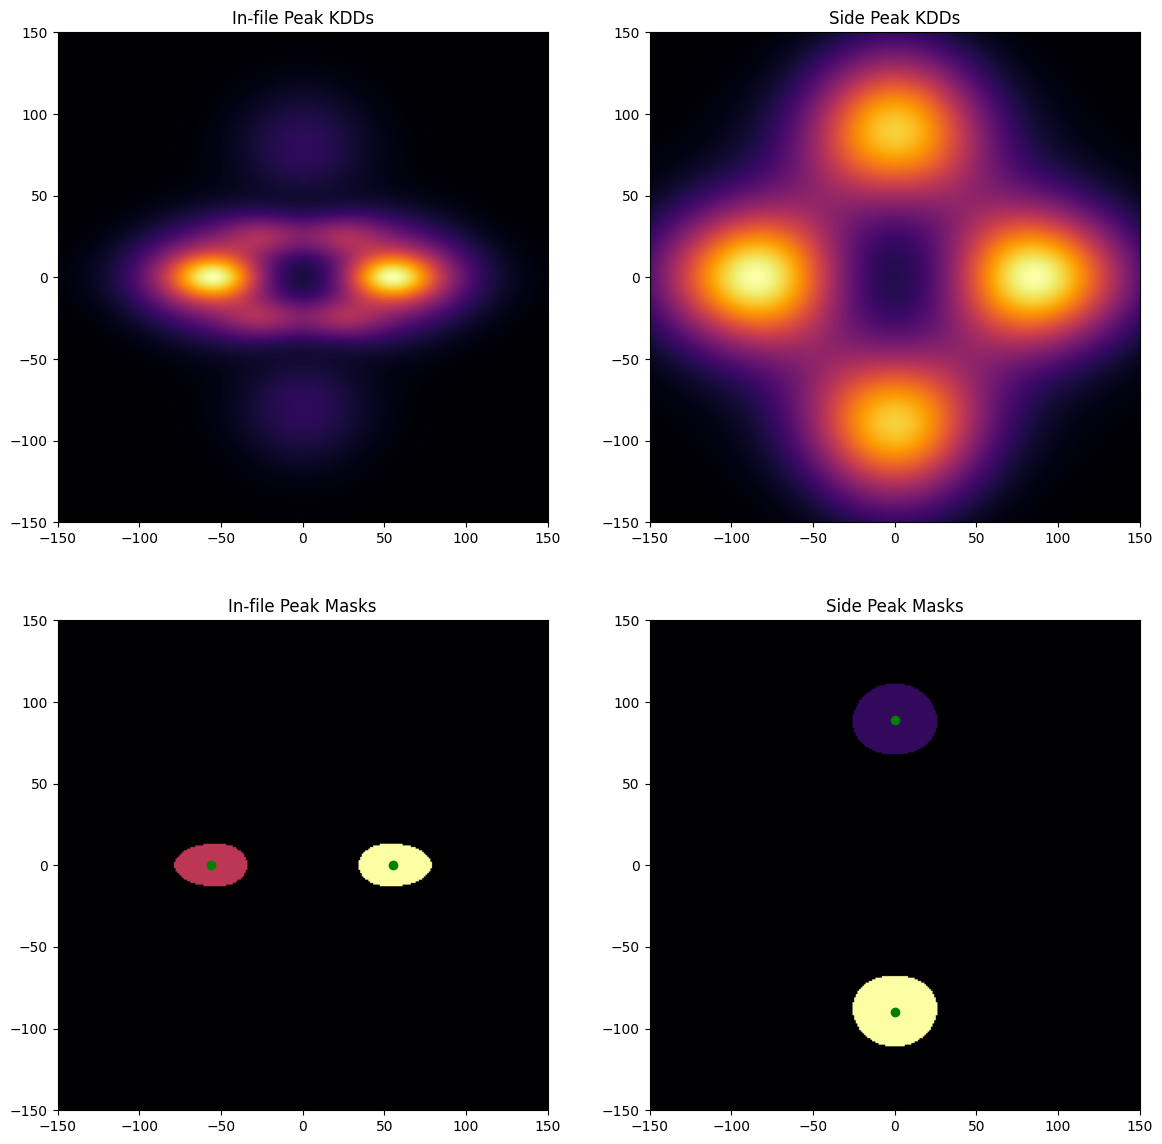

in-file:   len = 45.0 µm, wid = 26.0 µm, area = 1170.0 µm², centroid dist = 111.0 µm
side-file: len = 52.0 µm, wid = 43.0 µm, area = 2236.0 µm², centroid dist = 179.0 µm


In [ ]:
masking_val = 0.6
trench_thresh = origin_trench_dist
buffer = SCW_mu / 2

# normalize each rank's KDD by its max, average ranks 1-3 (in-file) and 4-5 (side-file)
Zrank = {k: SPP.stomata_KDDs(RepNNs, xbound, ybound, SCL_mu, SCW_mu, k, 'currank', False)
         for k in range(1, 6)}
Zif = SPP.stomata_KDD_rorshach(np.mean(
    [Zrank[k] / np.max(Zrank[k]) for k in (1, 2, 3)], axis=0))
Zsp = SPP.stomata_KDD_rorshach(np.mean(
    [Zrank[k] / np.max(Zrank[k]) for k in (4, 5)], axis=0))

if_len, if_wid, if_area, if_dist, sp_len, sp_wid, sp_area, sp_dist = \
    SPP.stomata_KDD_peak_spacing(Zif, Zsp, xbound, ybound, masking_val, trench_thresh, buffer, True)
print("in-file:   len =", np.round(if_len, 1), "µm, wid =", np.round(if_wid, 1),
      "µm, area =", np.round(if_area, 1), "µm², centroid dist =", np.round(if_dist, 1), "µm")
print("side-file: len =", np.round(sp_len, 1), "µm, wid =", np.round(sp_wid, 1),
      "µm, area =", np.round(sp_area, 1), "µm², centroid dist =", np.round(sp_dist, 1), "µm")

## 8. Null-model comparison (Observed vs Expected)

Following the paper's Supp. Fig. 2 logic, we generate a random-placement null (`stomata_nullNN`) with the same density and dimensions, build its KDD, and compute the **OEScore** — a global observed-vs-expected difference statistic. A large score means the real spatial patterning is more than simple geometric packing, as the paper concluded.
**ランダム配置の null モデルと比較し、OEScore を算出します（論文 Supp. Fig. 2 の論理）。**

1040 artificial coordinates generated for null model... (NOTE: Given sufficient replication the next phase can take some time!)


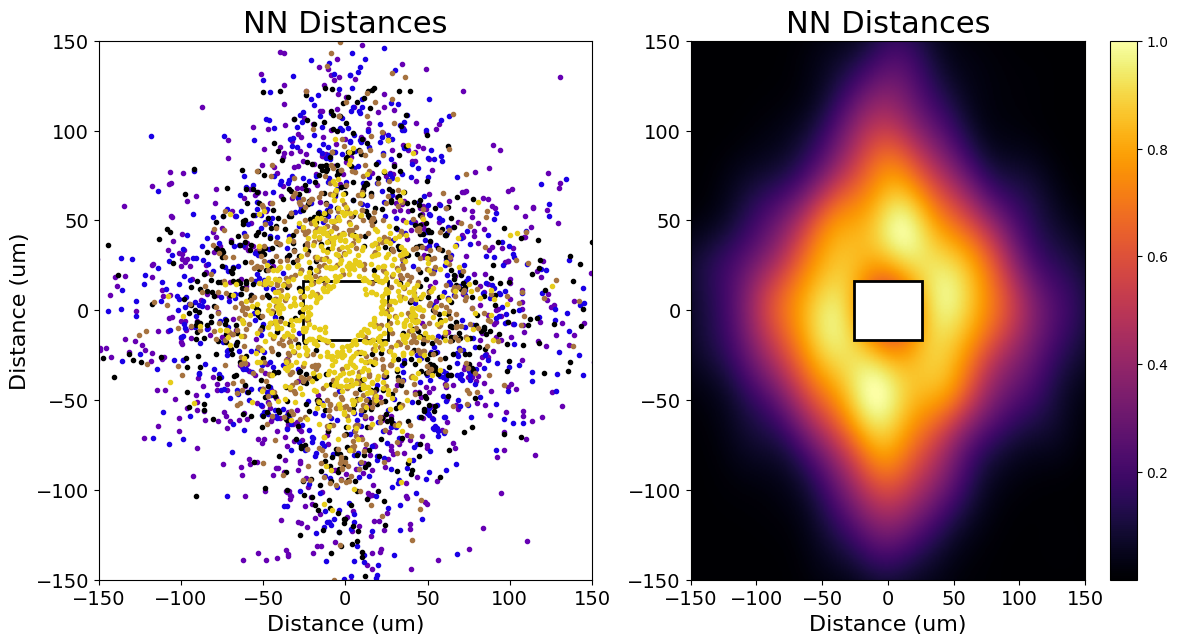

Observed vs Expected Score (observed vs random null): 17454.87


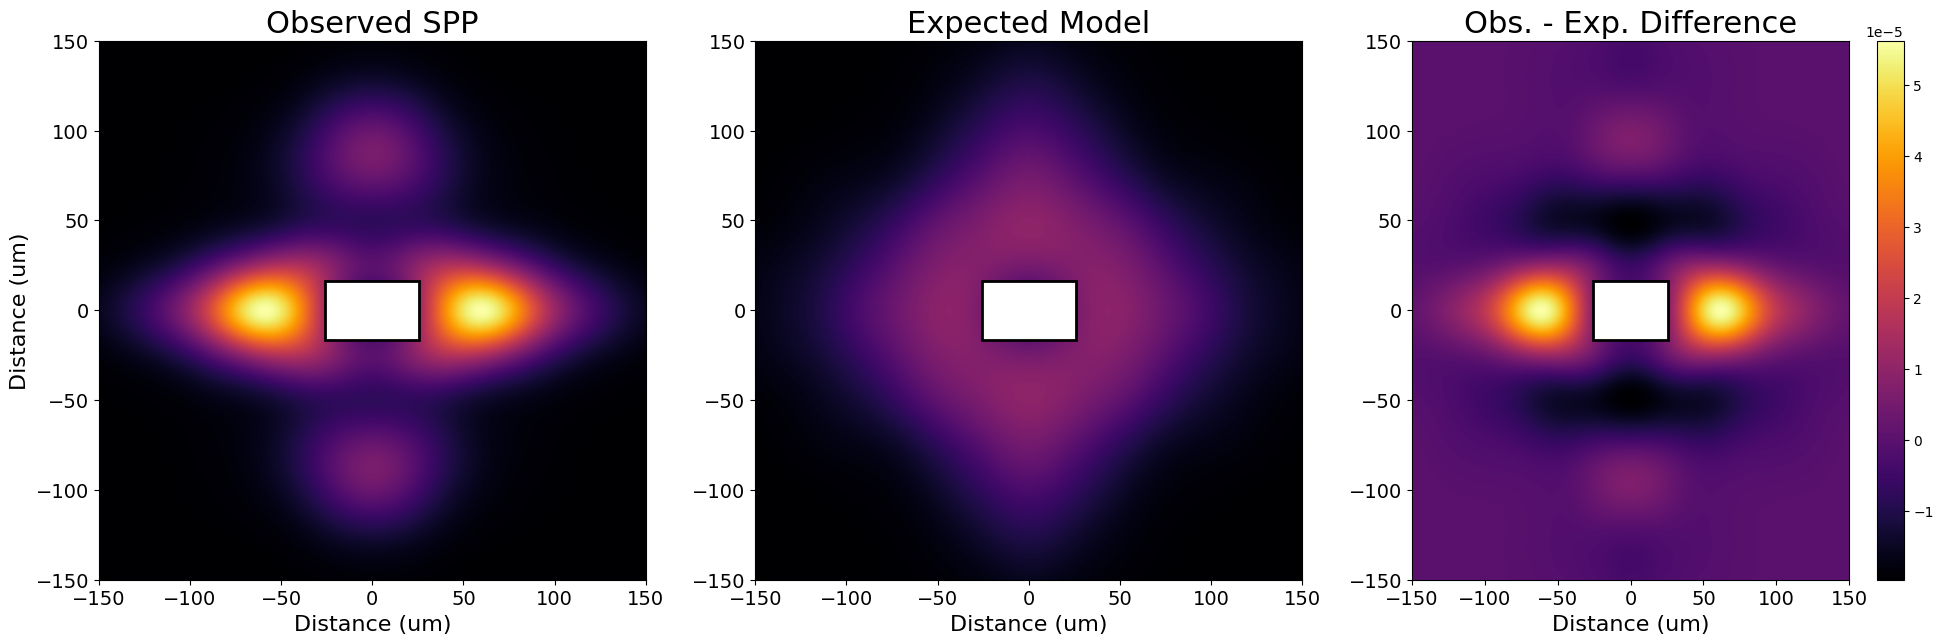

In [ ]:
RepZnorm = SPP.stomata_KDD_rorshach(RepZ, False)
nullNNs = SPP.stomata_nullNN(distance='M', rankno=ranks, ori_len=SCL_mu, ori_wid=SCW_mu,
                             xlim=img_size, ylim=img_size, n=int(np.round(SD_mu / 1.25)),
                             plotno=len(np.unique(AccNNs['Fieldplot'])),
                             repno=len(np.unique(AccNNs['Replicate'])),
                             techno=len(np.unique(AccNNs['FOV'])))
nullZ = SPP.stomata_KDDs(nullNNs, xbound, ybound, SCL_mu, SCW_mu, ranks, 'avgrank', plotting=True)
nullZnorm = SPP.stomata_KDD_rorshach(nullZ, False)

OEScore, DiffZ = SPP.stomata_compare_KDDs(RepZnorm, nullZnorm, xbound=xbound, ybound=ybound,
                                          ori_len=SCL_mu, ori_wid=SCW_mu, rankno=ranks, plotting=True)
print("Observed vs Expected Score (observed vs random null):", OEScore)

## 9. Trait summary table and CSV export

We combine every trait computed for this replicate into one table (with units) and save it as CSV inside Colab so you can download it.
**抽出した形質を 1 つの表にまとめ、CSV として保存します。**

In [ ]:
traits = pd.DataFrame([
    ("stomatal_density_stomata_per_field", SD_mu, "stomata / 512x512px field (x1.25)"),
    ("stomatal_complex_length", SCL_mu, "µm"),
    ("stomatal_complex_width", SCW_mu, "µm"),
    ("trench_distance", origin_trench_dist, "µm"),
    ("sidefile_peak_distance", origin_peak_dist, "µm"),
    ("in_file_probability", np.round(IF_prob, 3), "probability"),
    ("adjacent_file_probability", np.round(AF_prob, 3), "probability"),
    ("trench_probability", np.round(Tr_prob, 3), "probability"),
    ("sidefile_peak_probability", np.round(SP_prob, 3), "probability"),
    ("adjacent_file_origin_foldchange", np.round(Adjacprob_FC, 3), "fold-change"),
    ("trench_origin_foldchange", np.round(trenchprob_FC, 3), "fold-change"),
    ("sidefile_peak_origin_foldchange", np.round(Peaksprob_FC, 3), "fold-change"),
    ("in_file_variant_length", np.round(if_len, 2), "µm"),
    ("in_file_variant_width", np.round(if_wid, 2), "µm"),
    ("in_file_variant_area", np.round(if_area, 2), "µm²"),
    ("in_file_centroid_distance", np.round(if_dist, 2), "µm"),
    ("side_file_variant_length", np.round(sp_len, 2), "µm"),
    ("side_file_variant_width", np.round(sp_wid, 2), "µm"),
    ("side_file_variant_area", np.round(sp_area, 2), "µm²"),
    ("side_file_centroid_distance", np.round(sp_dist, 2), "µm"),
    ("null_comparison_OEScore", OEScore, "observed-vs-expected statistic"),
], columns=["trait", "value", "unit"])
traits.to_csv("/content/maize_SPP_traits_Z019E0047_rep1.csv", index=False)
print(traits.to_string(index=False))
print()
print("CSV saved to /content/maize_SPP_traits_Z019E0047_rep1.csv")

                             trait     value                              unit
stomatal_density_stomata_per_field    65.500 stomata / 512x512px field (x1.25)
           stomatal_complex_length    25.870                                µm
            stomatal_complex_width    16.320                                µm
                   trench_distance    67.500                                µm
            sidefile_peak_distance    86.000                                µm
               in_file_probability     0.012                       probability
         adjacent_file_probability     0.012                       probability
                trench_probability     0.002                       probability
         sidefile_peak_probability     0.002                       probability
   adjacent_file_origin_foldchange    -0.337                       fold-change
          trench_origin_foldchange    -0.851                       fold-change
   sidefile_peak_origin_foldchange    -0.821        

## 10. Interpretation and limitations

**What this demonstrated:** the paper's Python-computable core — rank-ordered Manhattan NN, the 1 µm²/±150 µm SPP kernel surface, derivative- and mask-based trait extraction, and a random-placement null comparison — runs end-to-end in minutes on the authors' example genotype, reproducing the qualitative grass signature (two in-file hotspots flanking the origin, diamond-like Manhattan geometry, OEScore > 0 versus the random null).

**What was NOT reproduced** (missing published material, per the paper and repo):
- R stages: dimension reduction, structural equation model (the 74% SD-variance claim), heritability, QTL mapping — no scripts distributed.
- Image annotation: Mask R-CNN weights not published; the Illinois Data Bank record (IDB-8275554) ships multi-GB archives, not used here.
- Population-level results across the RIL panel — this notebook runs one genotype × replicate of the authors' shipped example subset.

**日本語のまとめ:** 本ノートブックは論文の Python 部分（順位付き近傍 → SPP ヒートマップ → 形質抽出 → null 比較）を著者サンプルで実行しました。R による SEM・QTL 解析と Mask R-CNN アノテーションは未公開のため対象外です。単一遺伝子型・反復の実行であり、論文の集団レベルの結論の検証ではありません。

**References:** pySPP @ `84bd2c0` (MIT) — https://github.com/jgerardhodge/pySPP ; bioRxiv v1 preprint https://www.biorxiv.org/content/10.1101/2025.05.21.655366v1 ; published article DOI 10.1002/ppj2.70066.